## **UJIAN TENGAH SEMESTER KELOMPOK 2**

# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
%matplotlib inline

In [160]:
data = pd.read_csv("../data/diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [161]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [162]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [163]:
data.shape

(768, 9)

### **Exploratory Data Analysis**

In [164]:
d = data.describe()
d

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


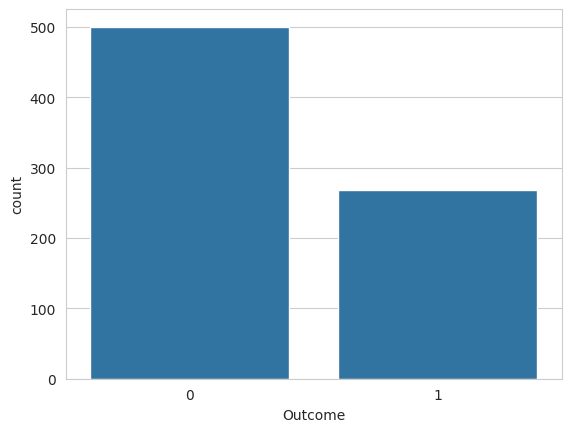

In [165]:
sns.countplot(x='Outcome', data=data)
plt.show()

<Axes: xlabel='Outcome', ylabel='count'>

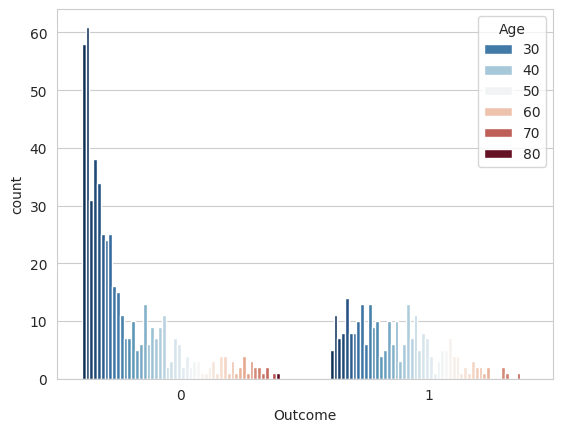

In [166]:
sns.set_style('whitegrid')
sns.countplot(x='Outcome', hue='Age', data=data, palette='RdBu_r')

<Axes: xlabel='Outcome', ylabel='count'>

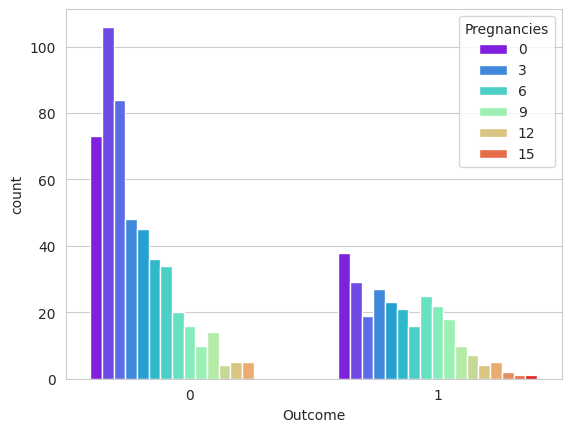

In [167]:
sns.set_style('whitegrid')
sns.countplot(x='Outcome', hue='Pregnancies', data=data, palette='rainbow')

/tmp/ipykernel_7674/689423686.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='BMI', data=data, palette='winter')


<Axes: xlabel='Outcome', ylabel='BMI'>

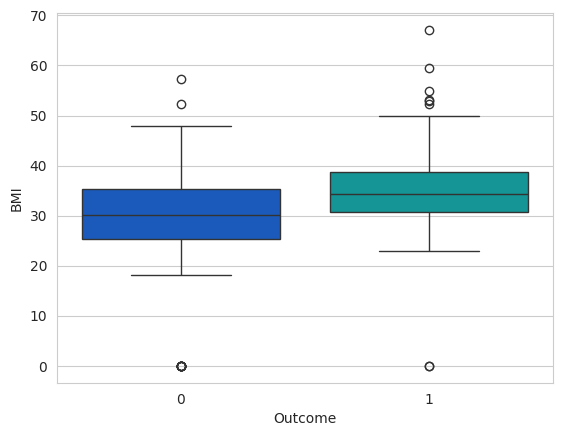

In [168]:
# Species vs SepalLength
sns.set_style('whitegrid')
sns.boxplot(x='Outcome', y='BMI', data=data, palette='winter')

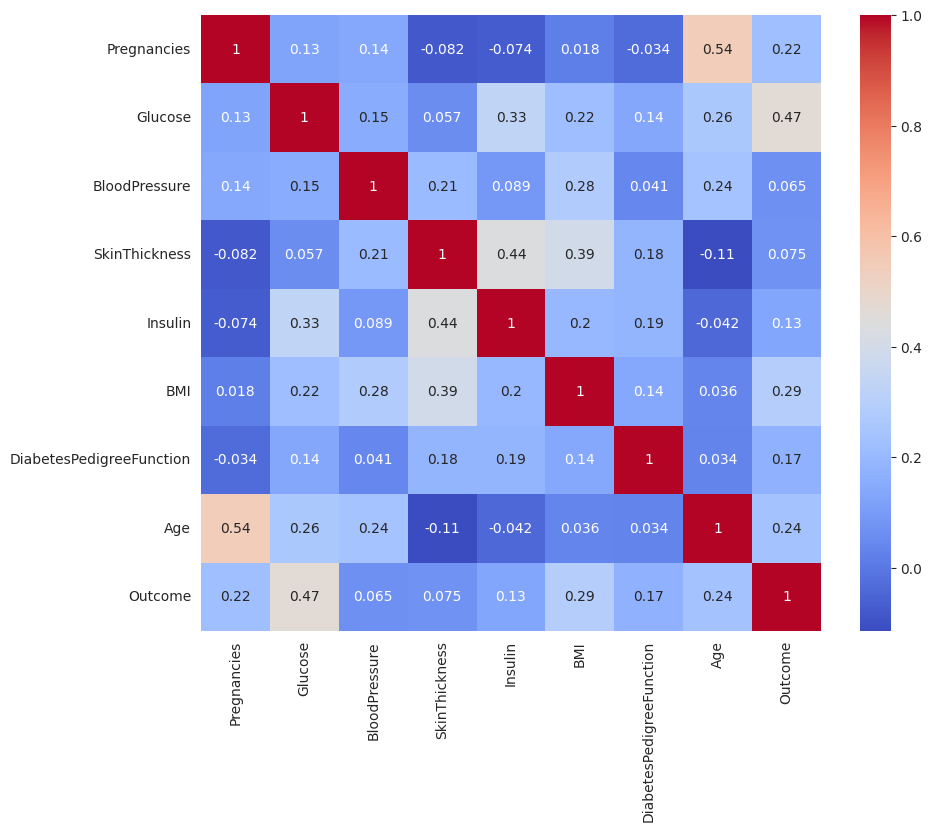

In [169]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

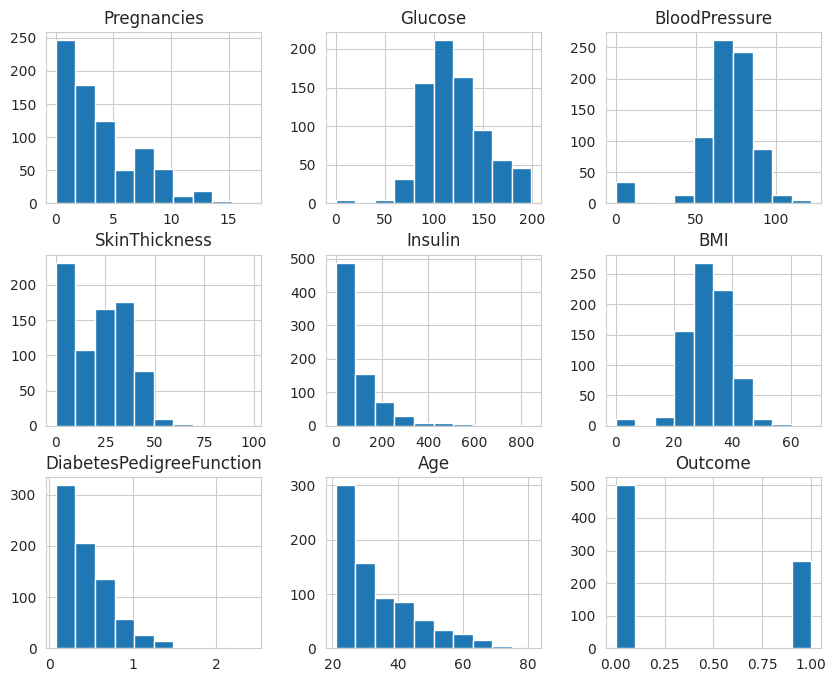

In [170]:
data.hist(figsize=(10,8))
plt.show()

<Axes: title={'center': 'Histogram usia pasien'}, xlabel='Usia pasien', ylabel='Count'>

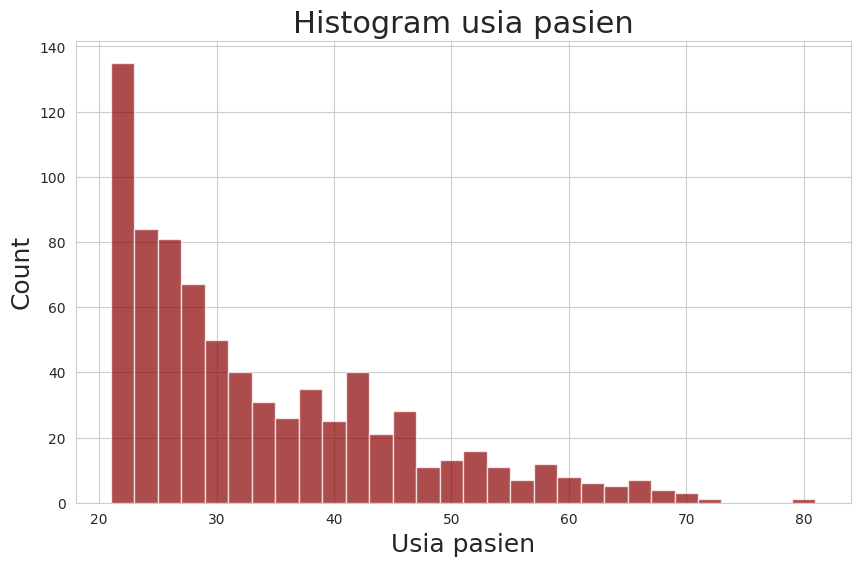

In [171]:
# Cek distribusi dari umur
plt.xlabel("Usia pasien",fontsize=18)
plt.ylabel("Count",fontsize=18)
plt.title("Histogram usia pasien",fontsize=22)
data['Age'].hist(bins=30,color='darkred',alpha=0.7,figsize=(10,6))

            Glucose
Outcome            
0        109.980000
1        141.257463


(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

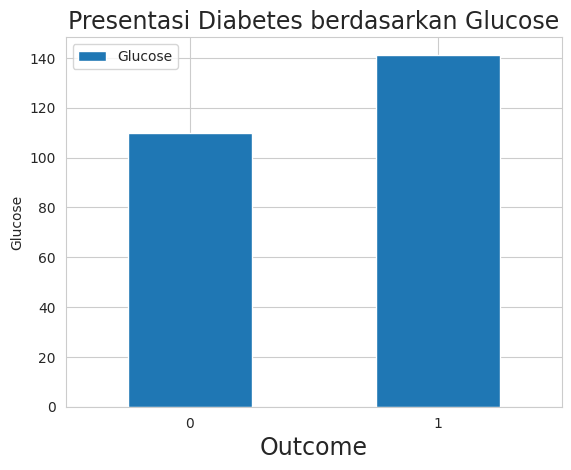

In [172]:
f_class_glukosa = data.groupby('Outcome')['Glucose'].mean()
f_class_glukosa = pd.DataFrame(f_class_glukosa)
print(f_class_glukosa)
f_class_glukosa
f_class_glukosa.plot.bar(y='Glucose')
plt.title("Presentasi Diabetes berdasarkan Glucose", fontsize=17)
plt.xlabel("Outcome", fontsize=17)
plt.ylabel("Glucose")
plt.xticks(rotation=0)

### Fitur Engineering

In [173]:
a = list(f_class_glukosa['Glucose'])

def  impute_diabetes(cols):
    DiabetesPid = cols['Glucose']
    Outcome = cols['Outcome']
    
    if pd.isnull(DiabetesPid):
        
        if Outcome == 0:
            return a[0]
        elif Outcome == 1:
            return a[1]
        else:
            return a[2]
    
    else:
        return DiabetesPid
                

In [174]:
data['Glucose'] = data[['Glucose', 'Outcome']].apply(impute_diabetes, axis=1)

Text(0.5, 1.0, 'Bar plot jumlah fitur numerik')

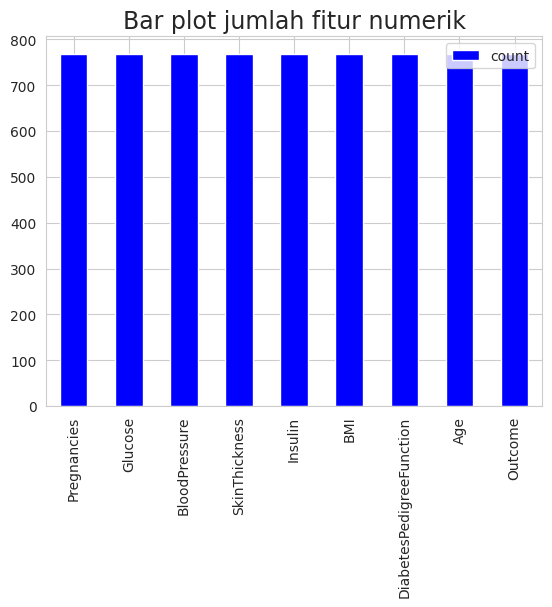

In [175]:
d = data.describe()
dT = d.T
dT.plot.bar(y='count', color='blue')
plt.title("Bar plot jumlah fitur numerik", fontsize=17)

In [176]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Outcome'] = le.fit_transform(data['Outcome'])
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### **Training**

In [177]:
X_train, X_test, y_train, y_test = train_test_split(data.drop('Outcome', axis=1),
                                                    data['Outcome'], test_size=0.30,
                                                    random_state=42)

In [178]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [179]:
print(f"Train shape {X_train.shape}")
print(f"Test shape {X_test.shape}")

Train shape (537, 8)
Test shape (231, 8)


# **MODEL**

## **KNN**

In [180]:
model_neighbors = KNeighborsClassifier()

model_neighbors.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [181]:
y_pred = model_neighbors.predict(X_test)

### Evaluation

In [182]:
accuracy = accuracy_score(y_test, y_pred) # Akurasi model
print(f'Akurasi Model KNN : {accuracy:.2f}')

print("Confusion Matrix : ") #Confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("classification_report : ")
print(classification_report(y_test, y_pred))

Akurasi Model KNN : 0.70
Confusion Matrix : 
[[119  32]
 [ 37  43]]
classification_report : 
              precision    recall  f1-score   support

           0       0.76      0.79      0.78       151
           1       0.57      0.54      0.55        80

    accuracy                           0.70       231
   macro avg       0.67      0.66      0.67       231
weighted avg       0.70      0.70      0.70       231



In [183]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred1 = clf2.predict(X_test)

In [184]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred1) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred1))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred1))

Akurasi Model KNN: 0.70
Confusion Matrix:
[[119  32]
 [ 38  42]]
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.79      0.77       151
           1       0.57      0.53      0.55        80

    accuracy                           0.70       231
   macro avg       0.66      0.66      0.66       231
weighted avg       0.69      0.70      0.69       231



In [185]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': range(1, 30), # [3, 5, 7]
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 116 candidates, totalling 580 fits



=== Hasil Evaluasi Training (Cross-Validation) ===
                                                params  ...  mean_test_f1
13   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...  ...      0.746027
12   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...  ...      0.736604
11   {'metric': 'euclidean', 'n_neighbors': 6, 'wei...  ...      0.730662
15   {'metric': 'euclidean', 'n_neighbors': 8, 'wei...  ...      0.728803
9    {'metric': 'euclidean', 'n_neighbors': 5, 'wei...  ...      0.726867
..                                                 ...  ...           ...
96   {'metric': 'manhattan', 'n_neighbors': 20, 'we...  ...      0.665755
64   {'metric': 'manhattan', 'n_neighbors': 4, 'wei...  ...      0.665071
100  {'metric': 'manhattan', 'n_neighbors': 22, 'we...  ...      0.663400
2    {'metric': 'euclidean', 'n_neighbors': 2, 'wei...  ...      0.647983
60   {'metric': 'manhattan', 'n_neighbors': 2, 'wei...  ...      0.632353

[116 rows x 5 columns]


In [186]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}


In [187]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi : {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi : {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall : {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score : {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report : ")
print(classification_report(y_test, y_pred))
print("Confusion Matrix : ")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi : 0.69
Presisi : 0.65
Recall : 0.64
F1-Score : 0.65

Classification Report : 
              precision    recall  f1-score   support

           0       0.75      0.79      0.77       151
           1       0.56      0.50      0.53        80

    accuracy                           0.69       231
   macro avg       0.65      0.64      0.65       231
weighted avg       0.68      0.69      0.68       231

Confusion Matrix : 
[[119  32]
 [ 40  40]]


In [188]:
# Data Pasien terbaru dengan urutan sama seperti fitur model
# Format = [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin. BMI. DiabetesPedigreeFunction, Age]

new_data = np.array([[5, 140, 40, 30, 90, 35.5, 0.600, 42]])

prediction = best_model.predict(new_data)

prediction_label = le.inverse_transform(prediction)

print("Prediski (0 : Tidak Diabetes, 1 : Diabetes) : ", prediction_label[0])



Prediski (0 : Tidak Diabetes, 1 : Diabetes) :  1


## **Naive Bayes**

In [189]:
from sklearn.naive_bayes import GaussianNB

model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

y_pred_nb = model_nb.predict(X_test)

### Evaluation

In [190]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_nb)
print(f'Akurasi Model Decision Tree: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

Akurasi Model Decision Tree: 0.74
Confusion Matrix:
[[119  32]
 [ 27  53]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.80       151
           1       0.62      0.66      0.64        80

    accuracy                           0.74       231
   macro avg       0.72      0.73      0.72       231
weighted avg       0.75      0.74      0.75       231



In [191]:
# Data Pasien terbaru dengan urutan sama seperti fitur model
# Format = [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin. BMI. DiabetesPedigreeFunction, Age]

new_data = np.array([[5, 140, 40, 30, 90, 35.5, 0.600, 42]])

new_prediction = model_nb.predict(new_data)

print("Prediski (0 : Tidak Diabetes, 1 : Diabetes) : ", new_prediction[0])

Prediski (0 : Tidak Diabetes, 1 : Diabetes) :  1


# **Decision Tree**

In [192]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(max_depth=3)

model_dt.fit(X_train, y_train)

# Prediksi data uji
y_pred_dt = model_dt.predict(X_test)

In [193]:
from sklearn import tree
test_representation = tree.export_text(model_dt)
print(test_representation)

|--- feature_1 <= 1.04
|   |--- feature_7 <= -0.39
|   |   |--- feature_1 <= 0.21
|   |   |   |--- class: 0
|   |   |--- feature_1 >  0.21
|   |   |   |--- class: 0
|   |--- feature_7 >  -0.39
|   |   |--- feature_5 <= -0.66
|   |   |   |--- class: 0
|   |   |--- feature_5 >  -0.66
|   |   |   |--- class: 0
|--- feature_1 >  1.04
|   |--- feature_5 <= -0.43
|   |   |--- feature_5 <= -0.87
|   |   |   |--- class: 1
|   |   |--- feature_5 >  -0.87
|   |   |   |--- class: 0
|   |--- feature_5 >  -0.43
|   |   |--- feature_6 <= 2.80
|   |   |   |--- class: 1
|   |   |--- feature_6 >  2.80
|   |   |   |--- class: 1



In [194]:
with open("decistion_tree.log", "w") as fout:
    fout.write(test_representation)

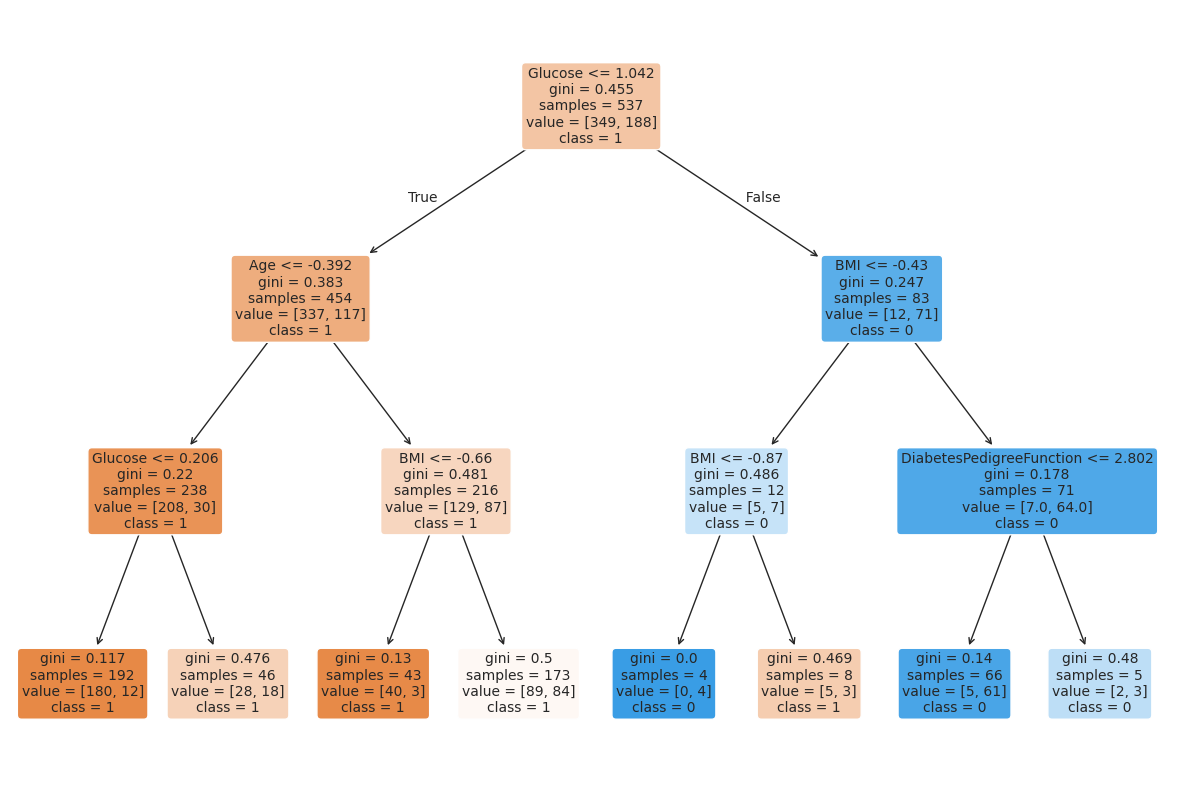

In [201]:
feature_name = data.drop('Outcome', axis=1).columns
class_names = [str(i) for i in data['Outcome'].unique()]

fig = plt.figure(figsize=(15, 10))
tree.plot_tree(model_dt, 
               feature_names=feature_name, 
               class_names=class_names, 
               filled=True, 
               rounded=True, 
               fontsize=10)

plt.savefig("Decision_Tree.jpg")
plt.show()

### Evaluation

In [196]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Akurasi Model Decision Tree: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

Akurasi Model Decision Tree: 0.72
Confusion Matrix:
[[141  10]
 [ 55  25]]
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.93      0.81       151
           1       0.71      0.31      0.43        80

    accuracy                           0.72       231
   macro avg       0.72      0.62      0.62       231
weighted avg       0.72      0.72      0.68       231



In [197]:
# Data Pasien terbaru dengan urutan sama seperti fitur model
# Format = [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin. BMI. DiabetesPedigreeFunction, Age]

new_data = np.array([[5, 140, 40, 30, 90, 35.5, 0.600, 42]])

new_prediction_dt = model_dt.predict(new_data)

print("Prediski (0 : Tidak Diabetes, 1 : Diabetes) : ", new_prediction_dt[0])

Prediski (0 : Tidak Diabetes, 1 : Diabetes) :  1
